In [1]:
import os
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import nibabel as nib
import h5py
from scipy.spatial import KDTree, cKDTree
from lameg.surf import interpolate_data
from lameg.viz import show_surface, color_map
import io
from PIL import Image
from base64 import b64decode


In [2]:
plt.rcParams.update({
    'font.size': 16,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})

In [3]:
def add_subplot_label(ax, label, x=-.21, y=1.225, fontsize=26):
    ax.text(x, y, label,  # Adjust left of y-axis
            transform=ax.transAxes,
            fontsize=fontsize, va='top', ha='right')


In [4]:
out_dir='../output/wb_simulations'
n_layers=11
win_size=50
snr=-20

In [5]:
# Mesh to use for forward model in the simulations
multilayer_mesh_fname = '/home/common/bonaiuto/cued_action_meg/derivatives/processed/sub-001/surf/multilayer.11.ds.link_vector.fixed.gii'

# Load multilayer mesh and compute the number of vertices per layer
mesh = nib.load(multilayer_mesh_fname)
verts_per_surf = int(mesh.darrays[0].data.shape[0]/n_layers)

pial_orig_mesh = nib.load('/home/common/bonaiuto/cued_action_meg/derivatives/processed/sub-001/surf/pial.gii')
pial_ds_mesh = nib.load('/home/common/bonaiuto/cued_action_meg/derivatives/processed/sub-001/surf/pial.ds.gii')

multilayer_vertices = mesh.darrays[0].data
multilayer_faces = mesh.darrays[1].data  # Face indices
multilayer_orientations = mesh.darrays[2].data  # Assuming this is the orientation vectors

pial_vertices = pial_orig_mesh.darrays[0].data  # Vertex coordinates
pial_faces = pial_orig_mesh.darrays[1].data  # Face indices

pial_ds_vertices = pial_ds_mesh.darrays[0].data  # Vertex coordinates
pial_ds_faces = pial_ds_mesh.darrays[1].data  # Face indices

scalp_mesh=nib.load('/home/common/bonaiuto/cued_action_meg/derivatives/processed/sub-001/t1wscalp_2562.surf.gii')
scalp_vertices = scalp_mesh.darrays[1].data  # Vertex coordinates
scalp_faces = scalp_mesh.darrays[0].data  # Face indices

orig_inflated=nib.load('/home/common/bonaiuto/cued_action_meg/derivatives/processed/sub-001/surf/inflated.gii')
ds_inflated=nib.load('/home/common/bonaiuto/cued_action_meg/derivatives/processed/sub-001/surf/inflated.ds.gii')

In [6]:
# Compute surface normals (if not already available)
def compute_normals(vertices, faces):
    normals = np.zeros_like(vertices)
    for i in range(faces.shape[0]):
        v0, v1, v2 = vertices[faces[i]]
        # Edge vectors
        edge1 = v1 - v0
        edge2 = v2 - v0
        # Cross product to get normal
        normal = np.cross(edge1, edge2)
        normal /= np.linalg.norm(normal)  # Normalize the normal
        normals[faces[i]] += normal
    normals /= np.linalg.norm(normals, axis=1)[:, np.newaxis]  # Normalize all normals
    return normals

normals = compute_normals(scalp_vertices, scalp_faces)

 # Build a KD-tree for the downsampled vertices
tree = cKDTree(scalp_vertices) # pylint: disable=not-callable

# Find the nearest neighbor in the downsampled mesh for each vertex in the original mesh
distances, indices = tree.query(pial_ds_vertices)

# Compute the dot product between the orientation and the normal vectors
dot_products = np.abs(np.einsum('ij,ij->i', normals[indices], multilayer_orientations[:verts_per_surf,:])) 

In [7]:
left_side_view=[-150, -25, -28,
                8, 2.5, -32,
                0.25, -0.37, 0.9]

In [8]:
# Plot colors and camera view
# Interpolate for display on the original inflated surface
interpolated_data = interpolate_data(orig_inflated, ds_inflated, dot_products)

c_range = [np.min(interpolated_data), np.max(interpolated_data)]
cam_view=[289, 32, -19,
          3.5, 29, 26,
          0, 0, 1]


# Plot change in power on each surface
colors,_ = color_map(
    interpolated_data, 
    "Spectral_r", 
    0, 
    1,
    norm='N'
)
plot = show_surface(orig_inflated, vertex_colors=colors, info=True, camera_view=left_side_view)

Output()

317496 vertices


In [9]:
plot.fetch_screenshot()

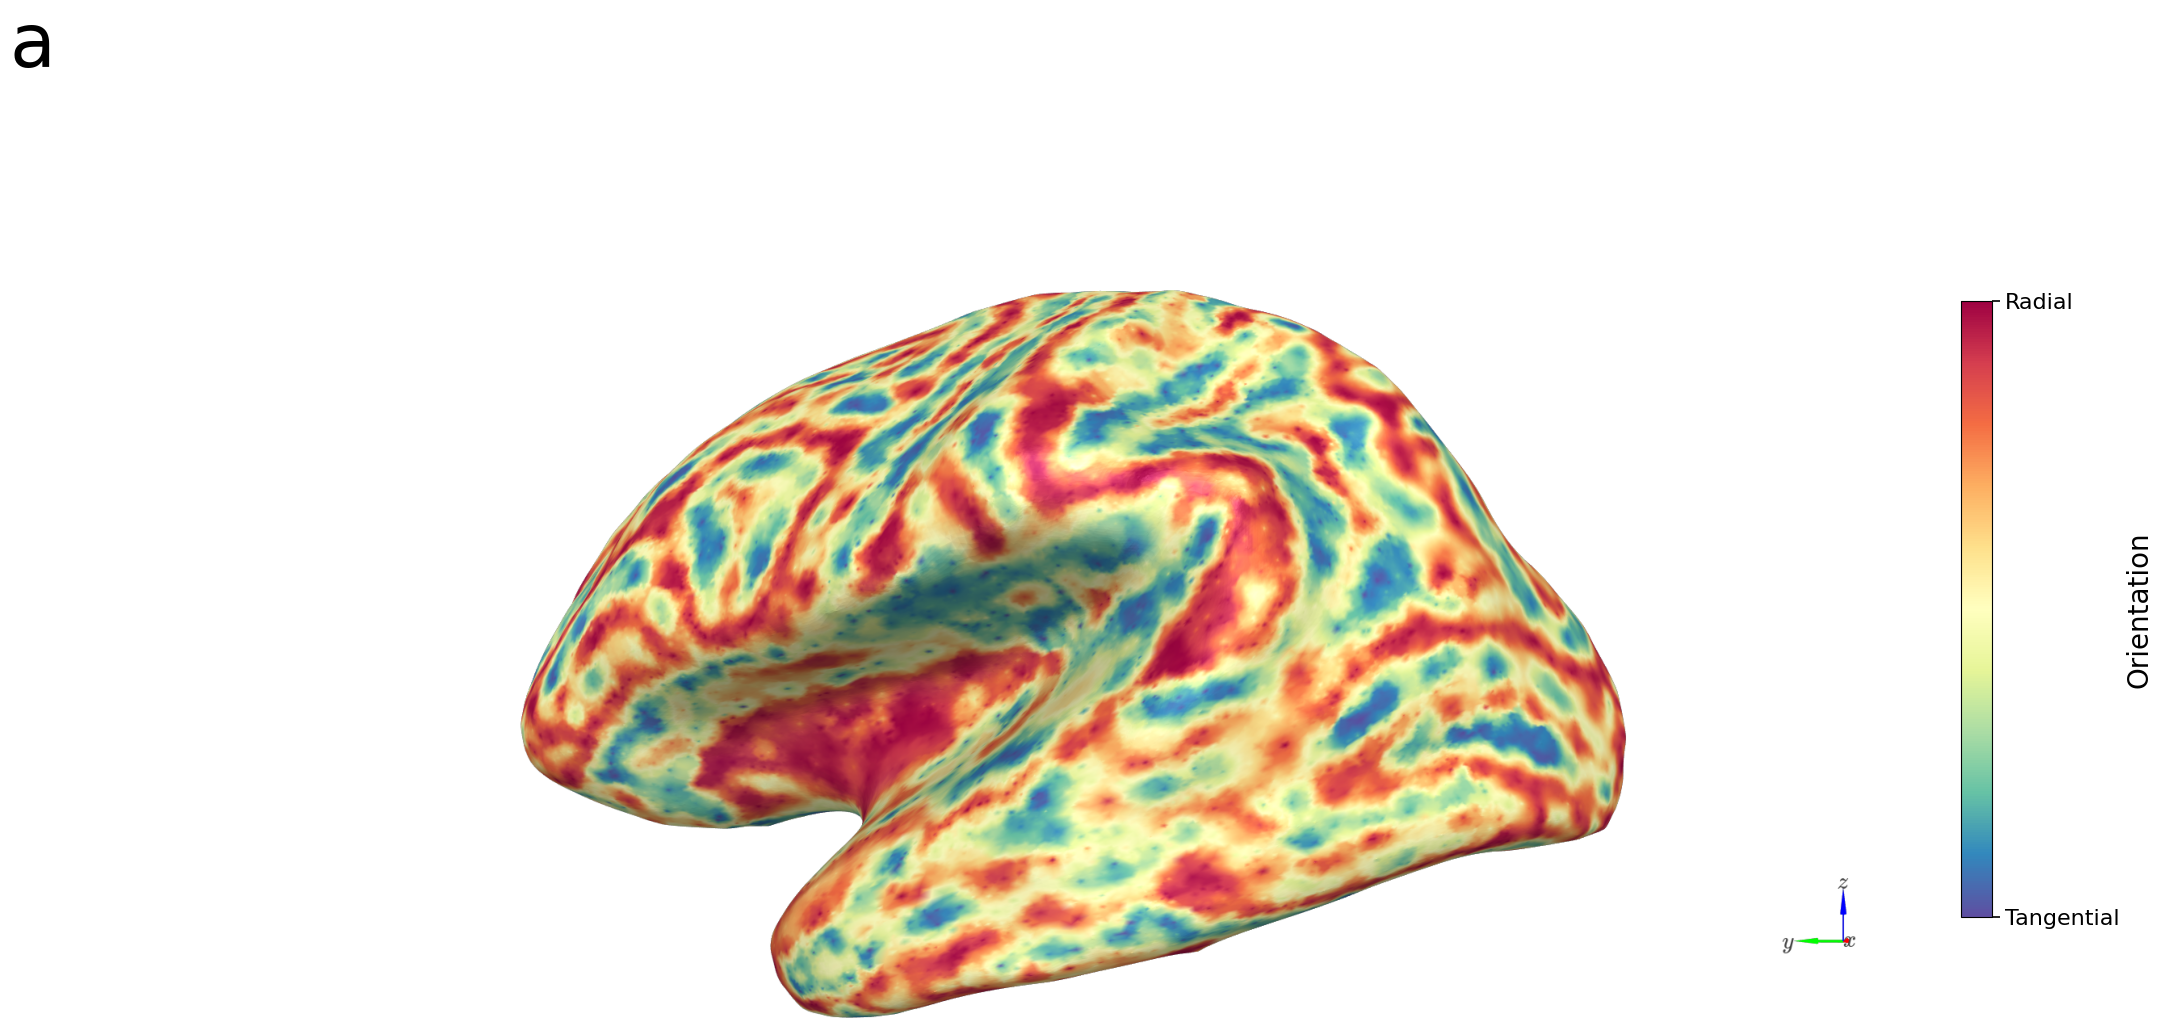

In [11]:
# Decode the screenshot
image_data = b64decode(plot.screenshot)
image = Image.open(io.BytesIO(image_data))
image_array = np.array(image)

# Set up figure and axis
fig, ax = plt.subplots(figsize=(24, 16))
ax.imshow(image_array)
ax.axis('off')  # Hide axes

# Create a ScalarMappable for the colorbar
vmin, vmax = np.min(interpolated_data), np.max(interpolated_data)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
scalar_mappable = cm.ScalarMappable(norm=norm, cmap="Spectral_r")

# Add colorbar
cbar = plt.colorbar(scalar_mappable, ax=ax, shrink=0.5, aspect=20, pad=0.02)
cbar.set_label("Orientation", fontsize=20)

# Set two ticks: at min (vmin) and max (vmax)
cbar.set_ticks([vmin, vmax])
cbar.set_ticklabels(["Tangential", "Radial"])

add_subplot_label(ax, 'a', fontsize=54)

# Show and save figure
plt.savefig(f"figure_06_orientation.pdf")


In [12]:
# Plot colors and camera view
interpolated_data = interpolate_data(orig_inflated, ds_inflated, distances)
c_range = [np.percentile(interpolated_data,1), np.percentile(interpolated_data,99)]
cam_view=[289, 32, -19,
          3.5, 29, 26,
          0, 0, 1]

# Plot change in power on each surface
colors,_ = color_map(
    interpolated_data, 
    "Spectral_r", 
    c_range[0], 
    c_range[1],
    norm='N'
)
plot = show_surface(orig_inflated, vertex_colors=colors, info=True, camera_view=left_side_view)

Output()

317496 vertices


In [13]:
plot.fetch_screenshot()

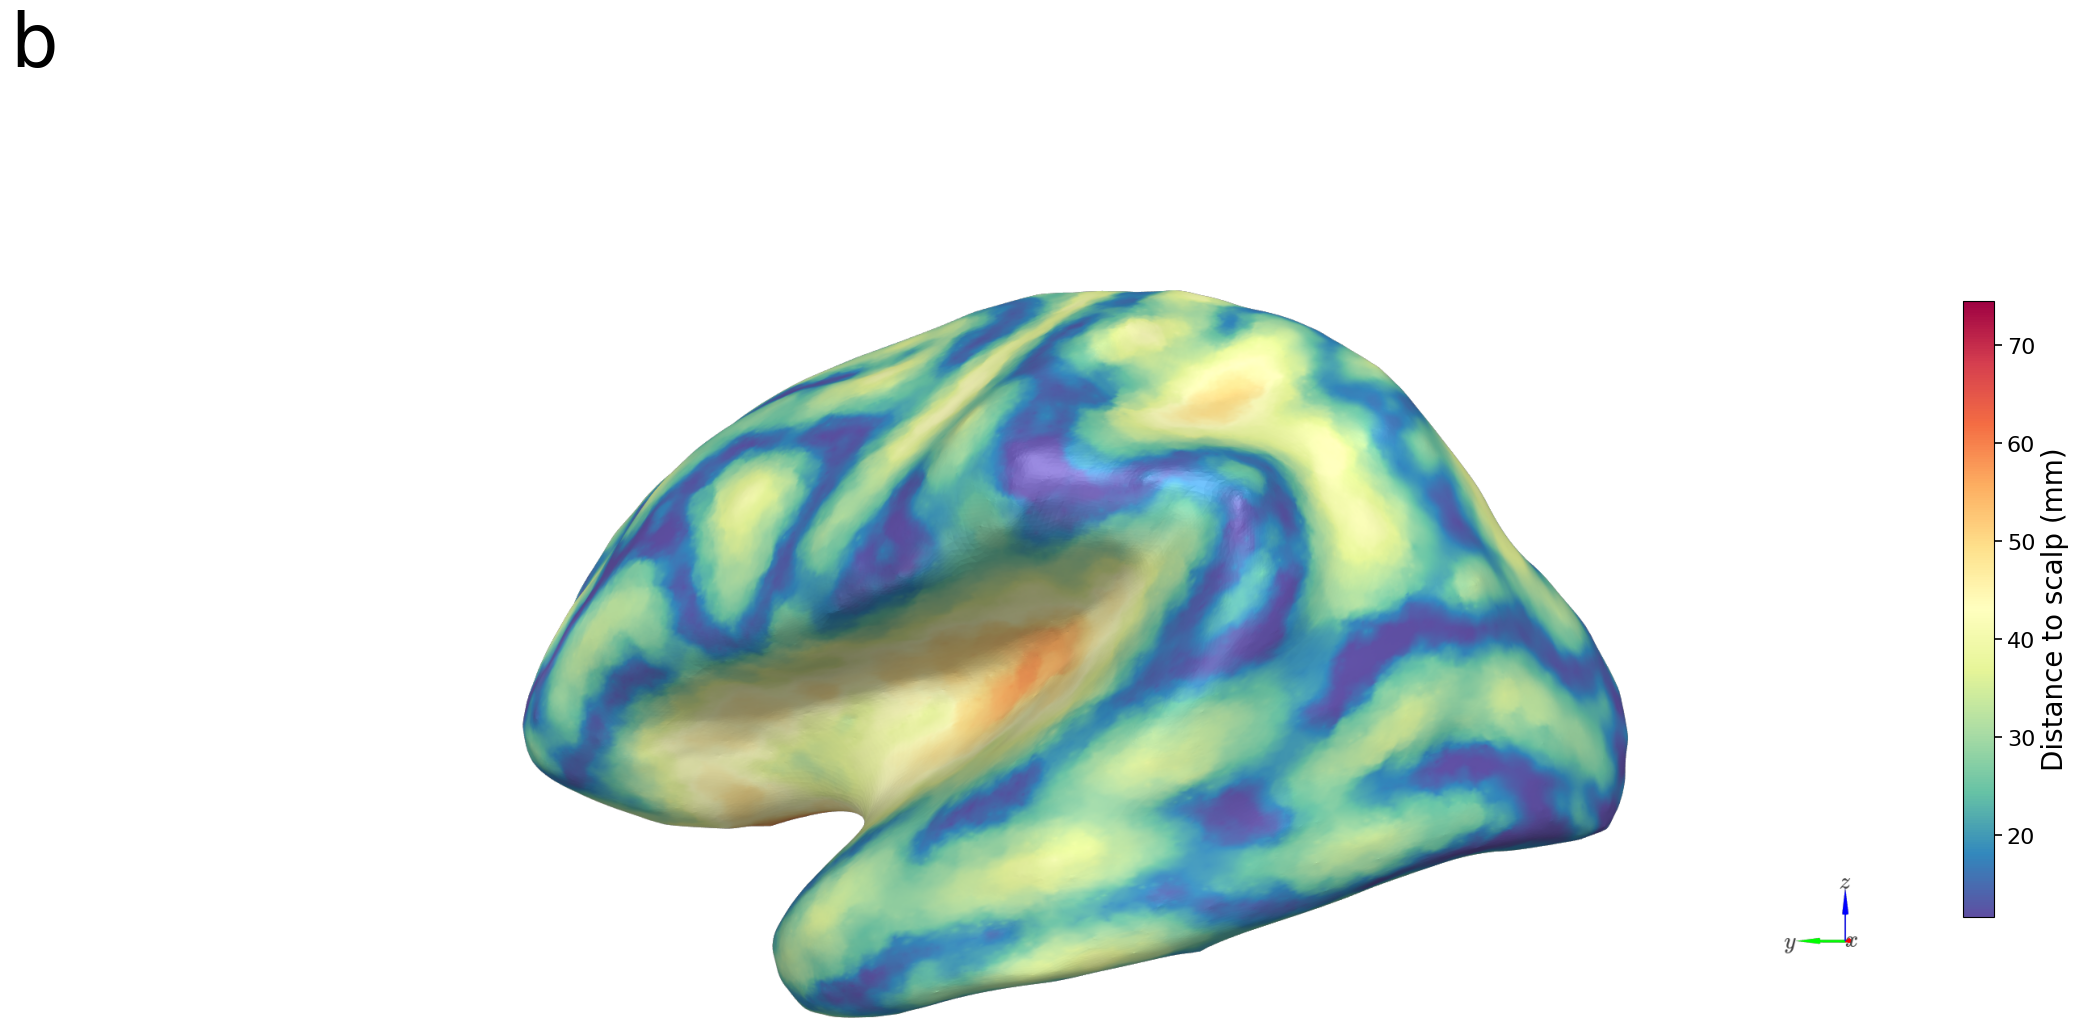

In [15]:
# Decode the screenshot
image_data = b64decode(plot.screenshot)
image = Image.open(io.BytesIO(image_data))
image_array = np.array(image)

# Set up figure and axis
fig, ax = plt.subplots(figsize=(24, 16))
ax.imshow(image_array)
ax.axis('off')  # Hide axes

# Create a ScalarMappable for the colorbar
vmin, vmax = np.min(interpolated_data), np.max(interpolated_data)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
scalar_mappable = cm.ScalarMappable(norm=norm, cmap="Spectral_r")

# Add colorbar
cbar = plt.colorbar(scalar_mappable, ax=ax, shrink=0.5, aspect=20, pad=0.02)
cbar.set_label("Distance to scalp (mm)", fontsize=20)

add_subplot_label(ax, 'b', fontsize=54)

# Show and save figure
plt.savefig(f"figure_06_distance.pdf")


In [8]:
gainmat='../output/wb_simulations/SPMgainmatrix_pcspm_converted_autoreject-sub-001-ses-01-motor-epo_1.mat'
with h5py.File(gainmat,'r') as file:
    lf_mat=file['G'][()]
lf_mat.shape

(320430, 275)

In [9]:
thickness=np.sqrt(np.sum((mesh.darrays[0].data[:verts_per_surf,:]-mesh.darrays[0].data[(n_layers-1)*verts_per_surf:,:])**2,axis=-1))

In [18]:
# Plot colors and camera view
interpolated_data = interpolate_data(orig_inflated, ds_inflated, thickness)
c_range = [np.percentile(interpolated_data,1), np.percentile(interpolated_data,99)]
cam_view=[289, 32, -19,
          3.5, 29, 26,
          0, 0, 1]

# Plot change in power on each surface
colors,_ = color_map(
    interpolated_data, 
    "Spectral_r", 
    c_range[0], 
    c_range[1],
    norm='N'
)
plot = show_surface(orig_inflated, vertex_colors=colors, info=True, camera_view=left_side_view)

Output()

317496 vertices


In [19]:
plot.fetch_screenshot()

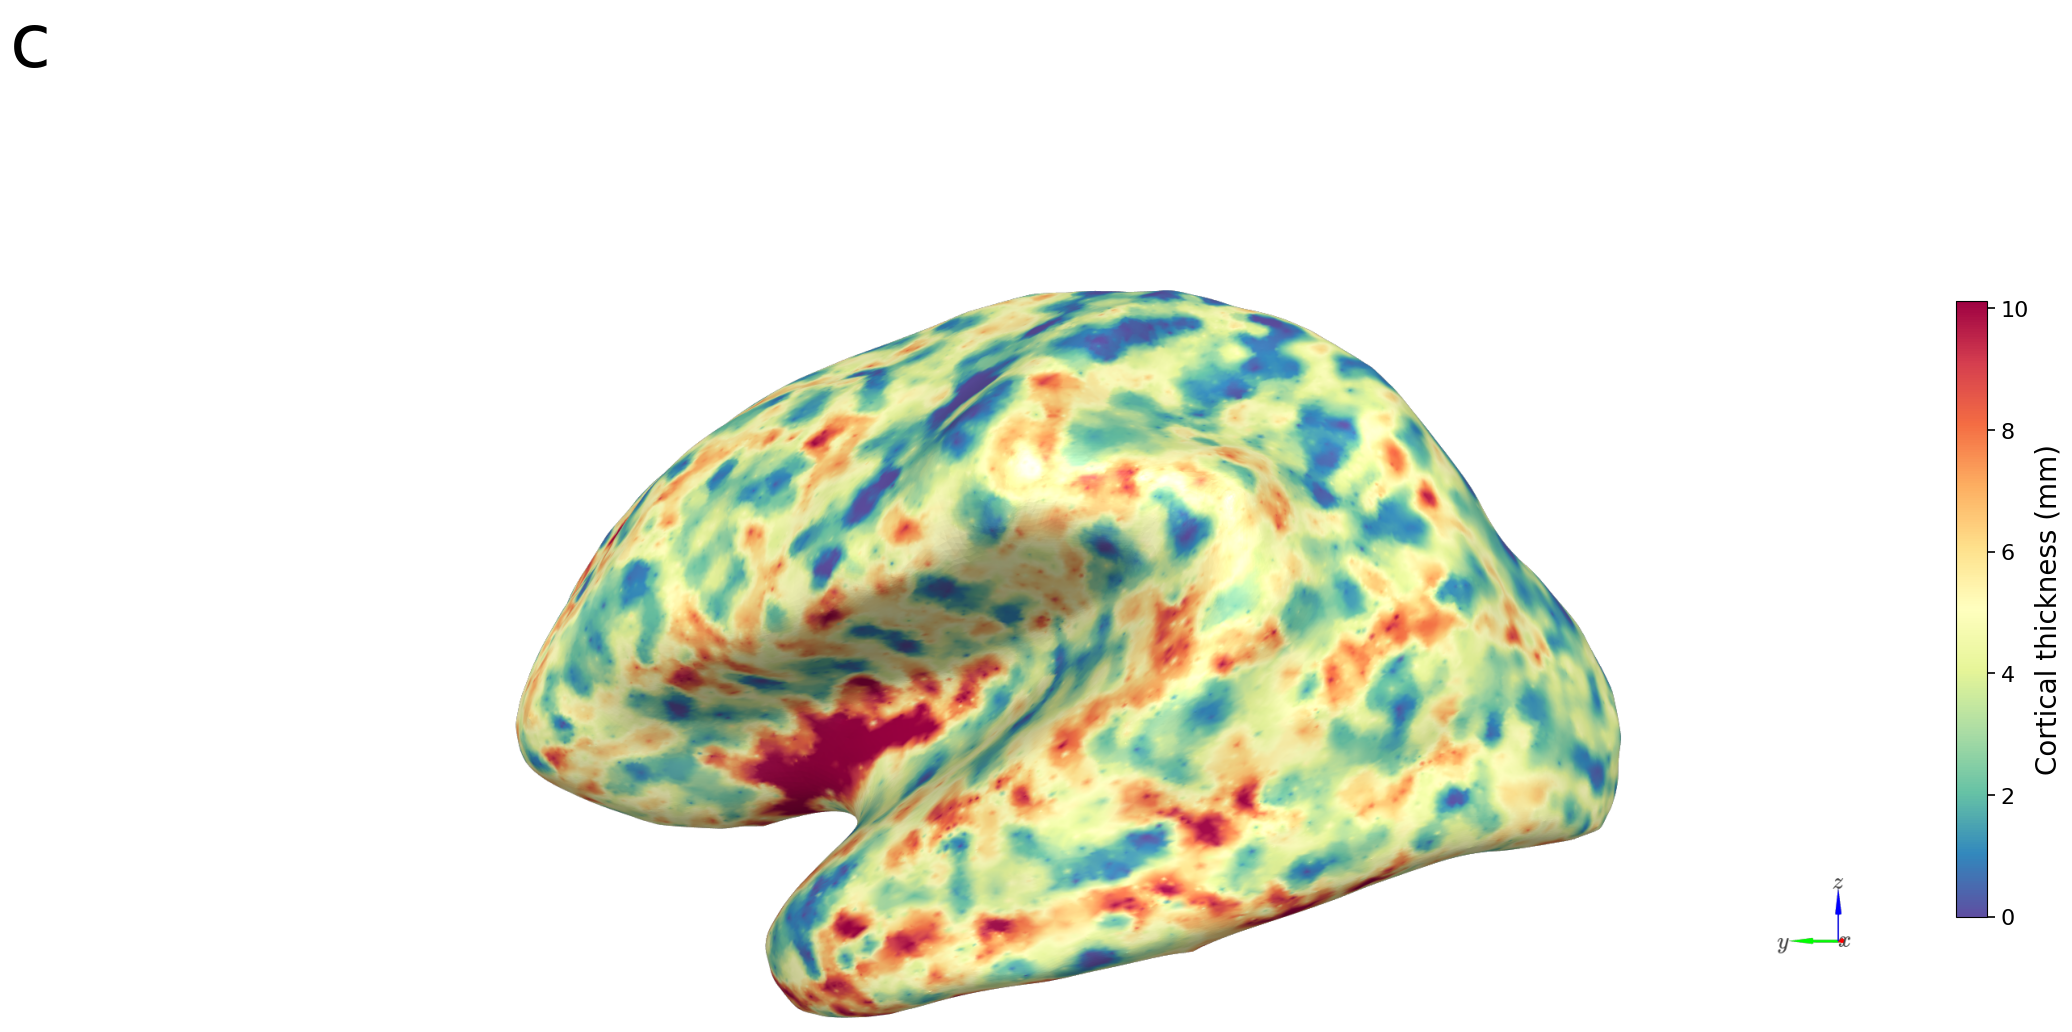

In [21]:
# Decode the screenshot
image_data = b64decode(plot.screenshot)
image = Image.open(io.BytesIO(image_data))
image_array = np.array(image)

# Set up figure and axis
fig, ax = plt.subplots(figsize=(24, 16))
ax.imshow(image_array)
ax.axis('off')  # Hide axes

# Create a ScalarMappable for the colorbar
vmin, vmax = np.min(interpolated_data), np.max(interpolated_data)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
scalar_mappable = cm.ScalarMappable(norm=norm, cmap="Spectral_r")

# Add colorbar
cbar = plt.colorbar(scalar_mappable, ax=ax, shrink=0.5, aspect=20, pad=0.02)
cbar.set_label("Cortical thickness (mm)", fontsize=20)

add_subplot_label(ax, 'c', fontsize=54)

# Show and save figure
plt.savefig(f"figure_06_thickness.pdf")


In [10]:
def compute_bias(matrix):
    if matrix.shape[0] != matrix.shape[1]:
        raise ValueError("The input matrix must be square.")
    
    n = matrix.shape[0]
    bias = np.zeros((n,1))
    
    # Loop through each column and check if the maximum value is on the diagonal
    for j in range(n):
        max_index = np.argmax(matrix[:, j])
        bias[j] = max_index-j 
    
    return np.mean(bias)


def compute_error(matrix):
    if matrix.shape[0] != matrix.shape[1]:
        raise ValueError("The input matrix must be square.")
    
    n = matrix.shape[0]
    error = np.zeros((n,1))
    
    # Loop through each column and check if the maximum value is on the diagonal
    for j in range(n):
        max_index = np.argmax(matrix[:, j])
        error[j] = np.abs(j-max_index)
    
    return np.mean(error)

In [11]:
v_idx=[]
bias_surf=[]
bias_mm=[]
error_surf=[]
error_mm=[]

fnames=sorted(glob.glob(os.path.join(out_dir, f'vx_*_snr_{snr}_winsize_{win_size}.pickle')))
for f_idx, fname in enumerate(fnames):
    with open(fname,'rb') as file:
        results=pickle.load(file)
    vertex=results['sim_vertex']
    norm_layerF = np.zeros((n_layers, n_layers))
    for l in range(n_layers):
        norm_layerF[:,l] = results['layerF'][:,l]-np.min(results['layerF'][:,l])                

    b = compute_bias(norm_layerF)
    e = compute_error(norm_layerF)
    v_idx.append(vertex)
    bias_surf.append(b)
    bias_mm.append(b*thickness[vertex])
    error_surf.append(e)
    error_mm.append(e*thickness[vertex])
v_idx=np.array(v_idx)
bias_surf=np.array(bias_surf)
bias_mm=np.array(bias_mm)
error_surf=np.array(error_surf)
error_mm=np.array(error_mm)

In [12]:
len(v_idx)

20404

In [41]:
error_mm[np.where(v_idx==5195)[0]]

array([0.])

In [118]:
layer_lf_mat=np.zeros((verts_per_surf, n_layers, lf_mat.shape[1]))
diff_layer_lf_mat=np.zeros((verts_per_surf, n_layers))
for i in range(n_layers):
    layer_lf_mat[:,i,:]=lf_mat[i*verts_per_surf:(i+1)*verts_per_surf,:]
for j in range(verts_per_surf):
    for i in range(n_layers):
        diff_layer_lf_mat[j,i]=np.sqrt(np.mean((layer_lf_mat[j,i,:]-layer_lf_mat[j,0,:])**2))

In [120]:
# Plot colors and camera view
interpolated_data = interpolate_data(orig_inflated, ds_inflated, diff_layer_lf_mat[:,-1])
c_range = [np.percentile(interpolated_data,1), np.percentile(interpolated_data,99)]
cam_view=[289, 32, -19,
          3.5, 29, 26,
          0, 0, 1]

# Plot change in power on each surface
colors,_ = color_map(
    interpolated_data, 
    "Spectral_r", 
    c_range[0], 
    c_range[1],
    norm='N'
)
plot = show_surface(orig_inflated, vertex_colors=colors, info=True, camera_view=left_side_view)

Output()

317496 vertices


In [29]:
plot.fetch_screenshot()

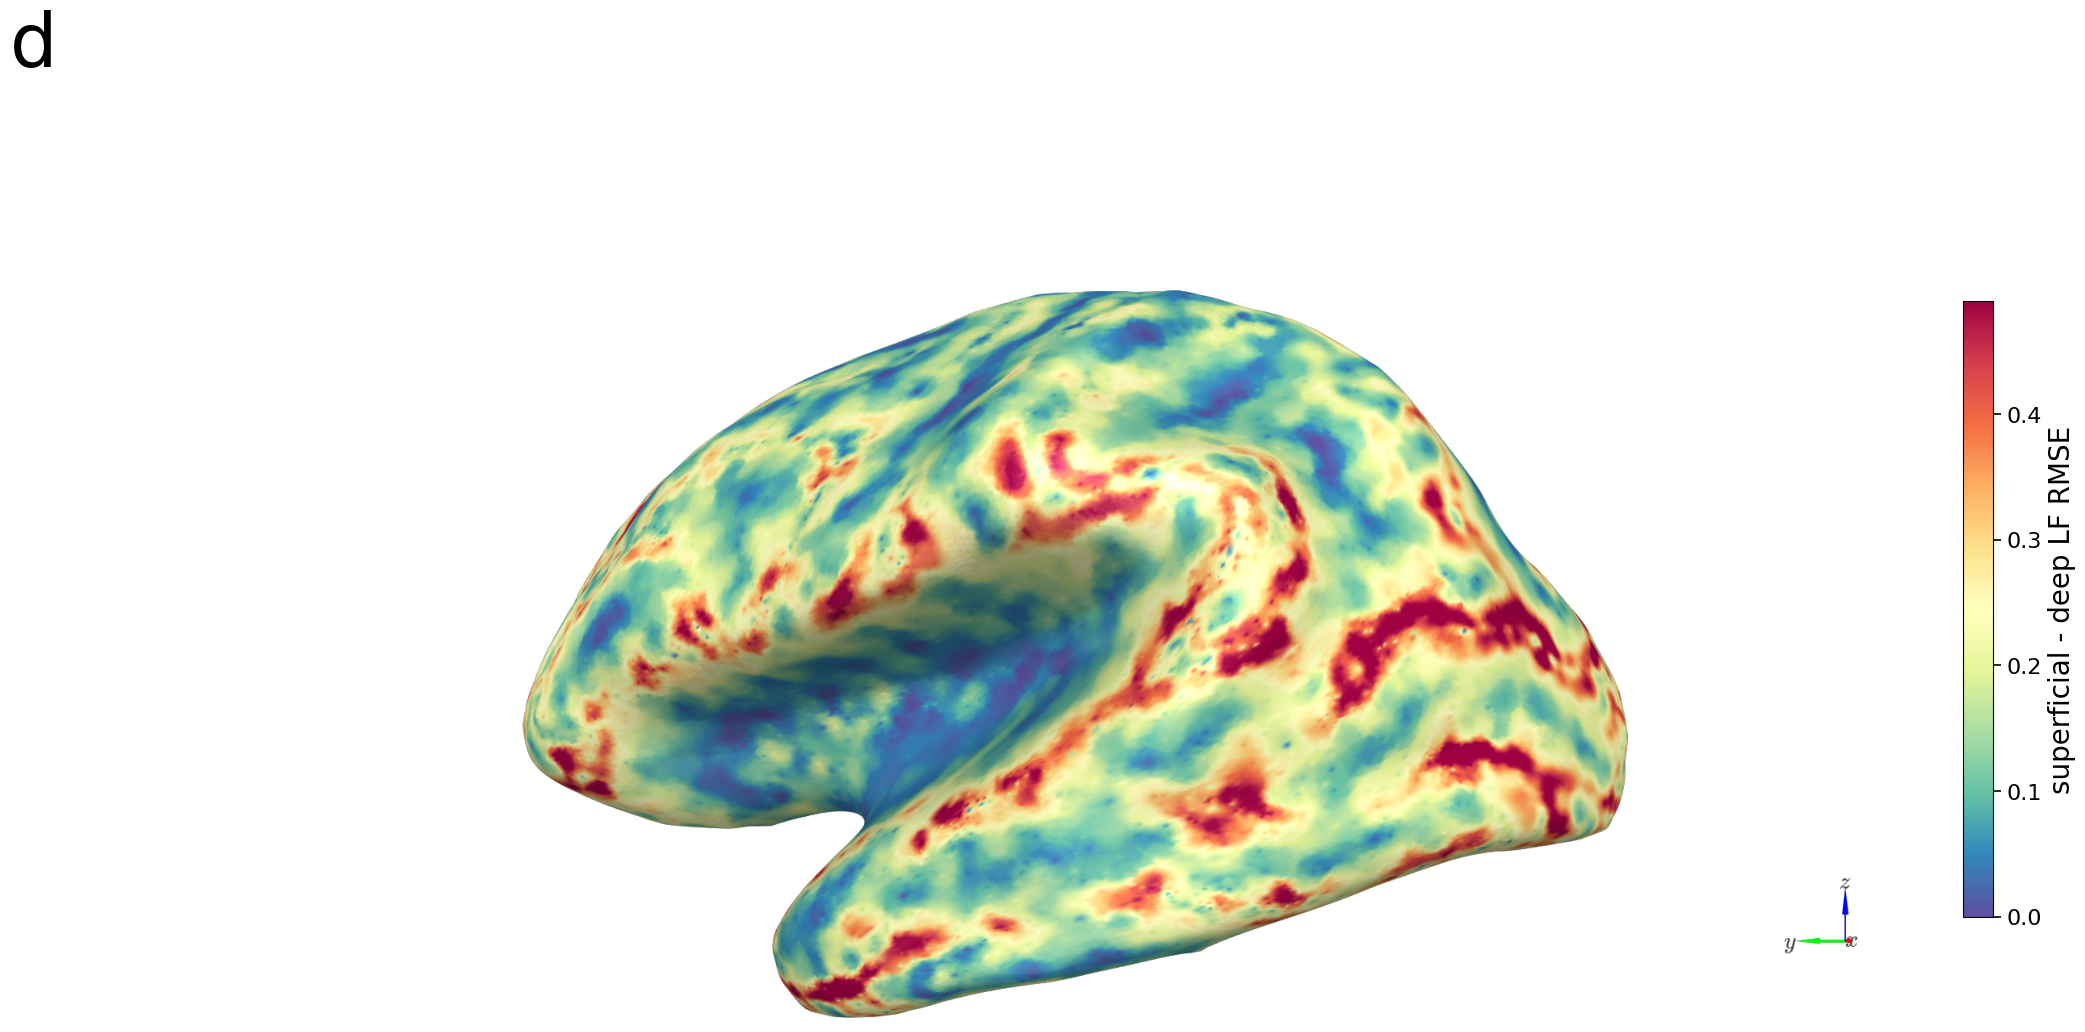

In [32]:
# Decode the screenshot
image_data = b64decode(plot.screenshot)
image = Image.open(io.BytesIO(image_data))
image_array = np.array(image)

# Set up figure and axis
fig, ax = plt.subplots(figsize=(24, 16))
ax.imshow(image_array)
ax.axis('off')  # Hide axes

# Create a ScalarMappable for the colorbar
vmin, vmax = np.min(interpolated_data), np.max(interpolated_data)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
scalar_mappable = cm.ScalarMappable(norm=norm, cmap="Spectral_r")

# Add colorbar
cbar = plt.colorbar(scalar_mappable, ax=ax, shrink=0.5, aspect=20, pad=0.02)
cbar.set_label("superficial - deep LF RMSE", fontsize=20)

add_subplot_label(ax, 'd', fontsize=54)

# Show and save figure
plt.savefig(f"figure_06_lead_field.pdf")

In [14]:
# Plot colors and camera view
error_all=np.zeros(verts_per_surf)
error_all[v_idx]=error_mm
interpolated_data = interpolate_data(orig_inflated, ds_inflated, error_all)
c_range = [0, np.percentile(interpolated_data,99.9)]
cam_view=[289, 32, -19,
          3.5, 29, 26,
          0, 0, 1]

# Plot change in power on each surface
colors,_ = color_map(
    interpolated_data, 
    "Spectral_r", 
    c_range[0], 
    c_range[1],
    norm='N'
)
plot = show_surface(orig_inflated, vertex_colors=colors, info=True, camera_view=left_side_view)

Output()

317496 vertices


In [34]:
plot.fetch_screenshot()

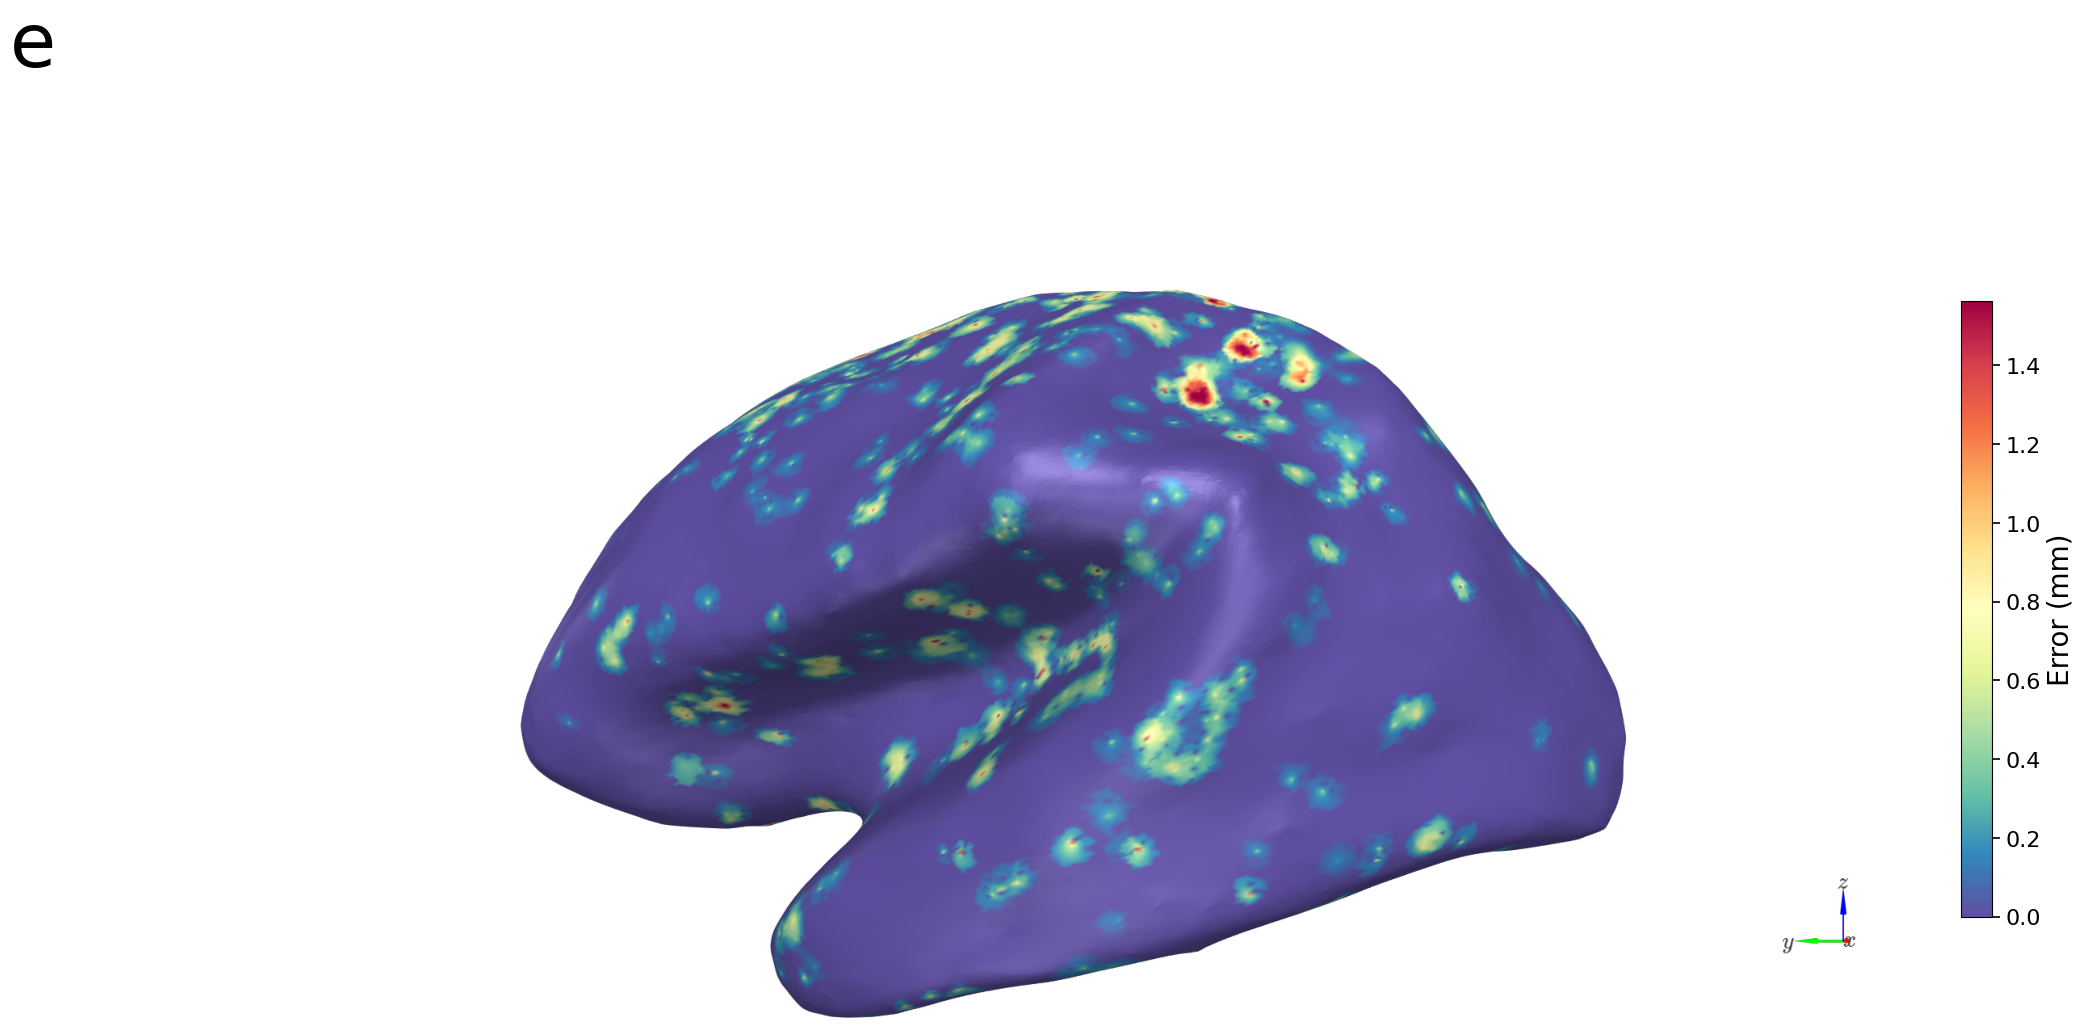

In [36]:
# Decode the screenshot
image_data = b64decode(plot.screenshot)
image = Image.open(io.BytesIO(image_data))
image_array = np.array(image)

# Set up figure and axis
fig, ax = plt.subplots(figsize=(24, 16))
ax.imshow(image_array)
ax.axis('off')  # Hide axes

# Create a ScalarMappable for the colorbar
vmin, vmax = np.min(interpolated_data), np.max(interpolated_data)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
scalar_mappable = cm.ScalarMappable(norm=norm, cmap="Spectral_r")

# Add colorbar
cbar = plt.colorbar(scalar_mappable, ax=ax, shrink=0.5, aspect=20, pad=0.02)
cbar.set_label("Error (mm)", fontsize=20)

add_subplot_label(ax, 'e', fontsize=54)

# Show and save figure
plt.savefig(f"figure_06_error_mm.pdf")

In [15]:
def plot_joint(x_vals, y_vals, error_mm, x_label, y_label, ax_label):
    x_l=np.percentile(x_vals,[.5,99.5])
    y_l=np.percentile(y_vals,[.5,99.5])
    idx=(x_vals>=x_l[0]) & (x_vals<=x_l[1]) & (y_vals>=y_l[0]) & (y_vals<=y_l[1])
    x_filt=x_vals[idx]
    y_filt=y_vals[idx]
    error_filt=error_mm[idx]
    # Example data (Replace with your actual data)
    x_blue = x_filt[error_filt == 0]  # Distance to scalp where error_mm == 0
    y_blue = y_filt[error_filt == 0]  # Lead Field RMSE where error_mm == 0

    x_red = x_filt[error_filt > 0]  # Distance to scalp where error_mm > 0
    y_red = y_filt[error_filt > 0]  # Lead Field RMSE where error_mm > 0

    # Create figure and scatter plot
    fig, ax_scatter = plt.subplots()
    ax_scatter.scatter(x_blue, y_blue, marker='.', c='b', edgecolors='none', alpha=0.3, label="error = 0",rasterized=True)
    ax_scatter.scatter(x_red, y_red, marker='.', c='r', edgecolors='none', alpha=0.3, label="error > 0",rasterized=True)
    ax_scatter.legend()

    ax_scatter.set_xlabel(x_label)
    ax_scatter.set_ylabel(y_label)

    # Create marginal histograms
    ax_histx = fig.add_axes([0.125, 0.9, 0.775, 0.2])  # X histogram (top)
    ax_histy = fig.add_axes([0.915, 0.11, 0.175, 0.775])  # Y histogram (right)

    ax_histx.hist(x_blue, bins=100, color='b', alpha=0.5, density=True)
    ax_histx.hist(x_red, bins=100, color='r', alpha=0.5, density=True)
    ax_histy.hist(y_blue, bins=100, color='b', alpha=0.5, density=True, orientation='horizontal')
    ax_histy.hist(y_red, bins=100, color='r', alpha=0.5, density=True, orientation='horizontal')

    # Hide tick labels on histograms
    ax_histx.set_xticks([])
    ax_histx.set_yticks([])
    ax_histx.set_ylabel('Density')
    ax_histy.set_xticks([])
    ax_histy.set_yticks([])
    ax_histy.set_xlabel('Density')

    for ax in [ax_scatter, ax_histx, ax_histy]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
    add_subplot_label(ax_scatter, ax_label,x=-.15, y=1.3)

In [203]:
import matplotlib.pyplot as plt
import numpy as np

def plot_joint(x_vals, y_vals, error_mm, x_label, y_label, ax_label):
    # Filter out extreme outliers
    x_l = np.percentile(x_vals, [0.5, 99.5])
    y_l = np.percentile(y_vals, [0.5, 99.5])
    idx = (
        (x_vals >= x_l[0]) & (x_vals <= x_l[1]) &
        (y_vals >= y_l[0]) & (y_vals <= y_l[1])
    )
    x_filt = x_vals[idx]
    y_filt = y_vals[idx]
    error_filt = error_mm[idx]

    # Sort by error so higher-error points get plotted last
    sort_idx = np.argsort(error_filt)
    x_sorted = x_filt[sort_idx]
    y_sorted = y_filt[sort_idx]
    err_sorted = error_filt[sort_idx]

    # Create figure and scatter plot with continuous colormap
    fig, ax_scatter = plt.subplots()
    sc = ax_scatter.scatter(
        x_sorted,
        y_sorted,
        c=err_sorted,
        cmap='plasma',
        marker='.',
        edgecolors='none',
        alpha=0.6,
        rasterized=True
    )
    ax_scatter.set_xlabel(x_label)
    ax_scatter.set_ylabel(y_label)

    # Add color bar for the scatter
    #cbar = fig.colorbar(sc, ax=ax_scatter)
    #cbar.set_label("Error (mm)")

    # Create marginal histograms
    ax_histx = fig.add_axes([0.125, 0.9, 0.775, 0.2])    # X histogram (top)
    ax_histy = fig.add_axes([0.915, 0.11, 0.175, 0.775]) # Y histogram (right)

    # --- Define bins for the marginal histograms ---

    # Bin 0: error == 0
    bin_0_mask = (err_sorted == 0)

    # For nonzero errors, split them into three tertiles
    nonzero_err = err_sorted[err_sorted > 0]
    # If everything is zero or there's only one unique error, handle gracefully
    if len(nonzero_err) < 2:
        # fallback: place everything else in one bin
        q1, q2 = 0, 0
    else:
        q1, q2 = np.quantile(nonzero_err, [1/3, 2/3])

    # Bin 1: 0 < error <= q1
    bin_1_mask = (err_sorted > 0) & (err_sorted <= q1)
    # Bin 2: q1 < error <= q2
    bin_2_mask = (err_sorted > q1) & (err_sorted <= q2)
    # Bin 3: error > q2
    bin_3_mask = (err_sorted > q2)

    # --- Choose colors from the same plasma colormap ---
    cmap = plt.get_cmap("plasma")
    color_0 = cmap(0.0)   # for error=0
    color_1 = cmap(0.3)   # for lowest tertile
    color_2 = cmap(0.6)   # for middle tertile
    color_3 = cmap(0.9)   # for highest tertile

    # --- Plot X-histograms ---
    # Bin 0: error=0
    ax_histx.hist(
        x_sorted[bin_0_mask],
        bins=100,
        color=color_0,
        alpha=0.5,
        density=True,
        label="Error=0"
    )
    # Bin 1
    ax_histx.hist(
        x_sorted[bin_1_mask],
        bins=50,
        color=color_1,
        alpha=0.5,
        density=True,
        label=f"0<Err?{q1:.2f}"
    )
    # Bin 2
    ax_histx.hist(
        x_sorted[bin_2_mask],
        bins=50,
        color=color_2,
        alpha=0.5,
        density=True,
        label=f"{q1:.2f}<Err?{q2:.2f}"
    )
    # Bin 3
    ax_histx.hist(
        x_sorted[bin_3_mask],
        bins=50,
        color=color_3,
        alpha=0.5,
        density=True,
        label=f"Err>{q2:.2f}"
    )

    # --- Plot Y-histograms (horizontal) ---
    ax_histy.hist(
        y_sorted[bin_0_mask],
        bins=100,
        color=color_0,
        alpha=0.5,
        density=True,
        orientation='horizontal'
    )
    ax_histy.hist(
        y_sorted[bin_1_mask],
        bins=50,
        color=color_1,
        alpha=0.5,
        density=True,
        orientation='horizontal'
    )
    ax_histy.hist(
        y_sorted[bin_2_mask],
        bins=50,
        color=color_2,
        alpha=0.5,
        density=True,
        orientation='horizontal'
    )
    ax_histy.hist(
        y_sorted[bin_3_mask],
        bins=50,
        color=color_3,
        alpha=0.5,
        density=True,
        orientation='horizontal'
    )

    # Hide axis ticks on histograms
    ax_histx.set_xticks([])
    ax_histx.set_yticks([])
    ax_histx.set_ylabel("Density")

    ax_histx.legend(loc='upper right', fontsize=8)

    ax_histy.set_xticks([])
    ax_histy.set_yticks([])
    ax_histy.set_xlabel("Density")

    # Hide top and right spines
    for ax in [ax_scatter, ax_histx, ax_histy]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Add subplot label (if you have a custom function)
    add_subplot_label(ax_scatter, ax_label, x=-0.15, y=1.3)


In [251]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from matplotlib.patches import Patch

def plot_joint_kde(x_vals, y_vals, error_mm, x_label, y_label, ax_label, x_per=[0,100],y_per=[0,100]):
    """
    This version ensures the right marginal KDE axis remains at the original size
    (e.g., [0.915, 0.11, 0.175, 0.775]), and the color bar is placed beyond x=1.0.
    You might need to adjust figure size or use plt.subplots_adjust() to avoid clipping.
    """

    # 1) Filter out outliers if needed
    x_l = np.percentile(x_vals, x_per)
    y_l = np.percentile(y_vals, y_per)
    idx = ((x_vals >= x_l[0]) & (x_vals <= x_l[1]) &
           (y_vals >= y_l[0]) & (y_vals <= y_l[1]))
    x_filt = x_vals[idx]
    y_filt = y_vals[idx]
    err_filt = error_mm[idx]

    # 2) Sort by error so higher-error points are on top
    sort_idx = np.argsort(err_filt)
    x_sorted = x_filt[sort_idx]
    y_sorted = y_filt[sort_idx]
    err_sorted = err_filt[sort_idx]

    # 3) Main scatter plot
    #    By default, this axis is around [0.125, 0.11, 0.775, 0.775].
    fig, ax_scatter = plt.subplots()
    sc = ax_scatter.scatter(
        x_sorted,
        y_sorted,
        c=err_sorted,
        cmap='plasma',
        marker='.',
        edgecolors='none',
        alpha=0.6,
        rasterized=True
    )
    ax_scatter.set_xlabel(x_label)
    ax_scatter.set_ylabel(y_label)

    # 4) Top marginal axis (KDE in X dimension).
    #    For example, [0.125, 0.9, 0.775, 0.2].
    ax_histx = fig.add_axes([0.125, 0.9, 0.775, 0.2])

    # 5) Right marginal axis (KDE in Y dimension), full original width:
    #    e.g. [0.915, 0.11, 0.175, 0.775].
    #    We do NOT shrink it.
    ax_histy = fig.add_axes([0.915, 0.11, 0.175, 0.775])

    # 6) Add the color bar axis EVEN FARTHER to the right, e.g. x=1.095
    #    That means the figure's total width in normalized coords is ~1.115.
    ax_cbar = fig.add_axes([1.095, 0.11, 0.02, 0.775])
    cbar = fig.colorbar(sc, cax=ax_cbar)
    cbar.set_label("Error (mm)")

    # 7) Define one bin for error=0, plus N equally spaced bins for errors>0
    bin_0_mask = (err_sorted == 0)
    nonzero_err = err_sorted[err_sorted > 0]

    if len(nonzero_err) <= 1:
        # If everything is zero or there's only one unique nonzero error
        nonzero_bins = np.array([0, 1])
    else:
        num_nonzero_bins = 3  # e.g., 3 bins
        min_err = nonzero_err.min()
        max_err = nonzero_err.max()
        nonzero_bins = np.linspace(min_err, max_err, num_nonzero_bins + 1)

    # Build bin masks
    bin_masks  = []
    bin_colors = []
    
    cmap = plt.get_cmap("plasma")

    color_0 = cmap(0.0)
    bin_masks.append(bin_0_mask)
    bin_colors.append(color_0)
    
    color_increments = np.linspace(0.2, 0.9, num_nonzero_bins)
    for i in range(num_nonzero_bins):
        low  = nonzero_bins[i]
        high = nonzero_bins[i+1]
        if i < num_nonzero_bins - 1:
            mask = (err_sorted >= low) & (err_sorted < high)
        else:
            mask = (err_sorted >= low) & (err_sorted <= high)
        
        bin_masks.append(mask)
        bin_color = cmap(color_increments[i])
        bin_colors.append(bin_color)

    # 8) KDE plotting
    from scipy.stats import gaussian_kde
    def plot_kde_x(data, color):
        if len(data) < 2:
            return
        kde = gaussian_kde(data)
        x_grid = np.linspace(x_filt.min(), x_filt.max(), 200)
        pdf = kde(x_grid)
        ax_histx.plot(x_grid, pdf, color=color, alpha=0.8, lw=1.5)
        ax_histx.fill_between(x_grid, pdf, color=color, alpha=0.2)

    def plot_kde_y(data, color):
        if len(data) < 2:
            return
        kde = gaussian_kde(data)
        y_grid = np.linspace(y_filt.min(), y_filt.max(), 200)
        pdf = kde(y_grid)
        ax_histy.plot(pdf, y_grid, color=color, alpha=0.8, lw=1.5)
        ax_histy.fill_betweenx(y_grid, 0, pdf, color=color, alpha=0.2)

    # 9) Plot the KDE for each bin
    for mask, color in zip(bin_masks, bin_colors):
        plot_kde_x(x_sorted[mask], color)
        plot_kde_y(y_sorted[mask], color)

    # 10) Style marginal axes
    ax_histx.set_xticks([])
    ax_histx.set_yticks([])
    ax_histx.set_ylabel("KDE")

    ax_histy.set_xticks([])
    ax_histy.set_yticks([])
    ax_histy.set_xlabel("KDE")

    # 11) Hide top and right spines
    for ax in [ax_scatter, ax_histx, ax_histy]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # 12) Possibly adjust figure size or use plt.subplots_adjust() if needed
    #     For example, to ensure nothing is clipped:
    # plt.subplots_adjust(right=1.08)  # or more

    # 13) Add subplot label if desired
    add_subplot_label(ax_scatter, ax_label, x=-0.15, y=1.3)


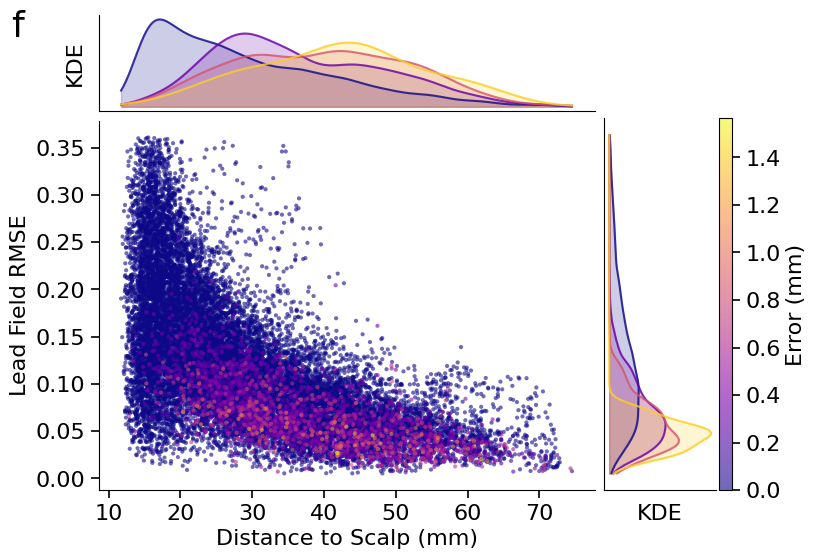

In [261]:
ax=plot_joint_kde(distances[v_idx], diff_layer_lf_mat[v_idx,-1], error_mm, 'Distance to Scalp (mm)', 'Lead Field RMSE','f',y_per=[.1,99.1])
plt.savefig(f"figure_06_dist_lf.pdf", bbox_inches='tight')

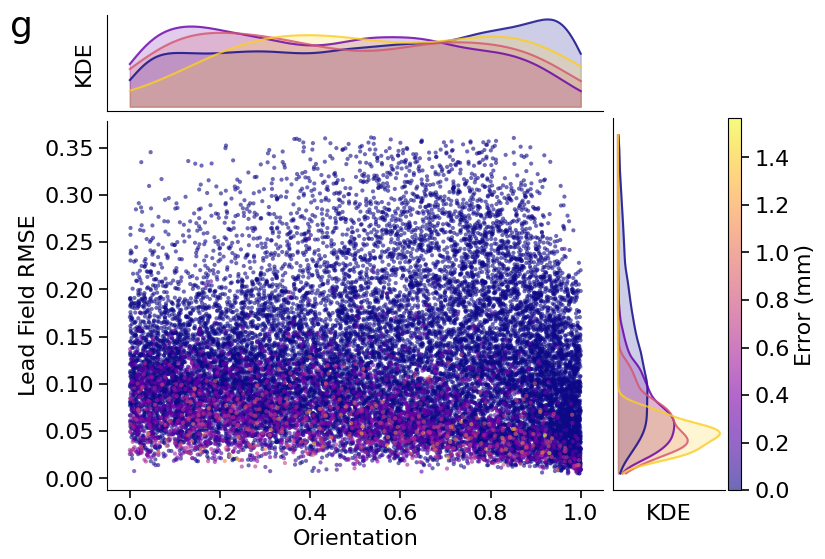

In [262]:
plot_joint_kde(dot_products[v_idx], diff_layer_lf_mat[v_idx,-1], error_mm, 'Orientation', 'Lead Field RMSE','g',y_per=[.1,99.1])
plt.savefig(f"figure_06_ori_lf.pdf", bbox_inches='tight')

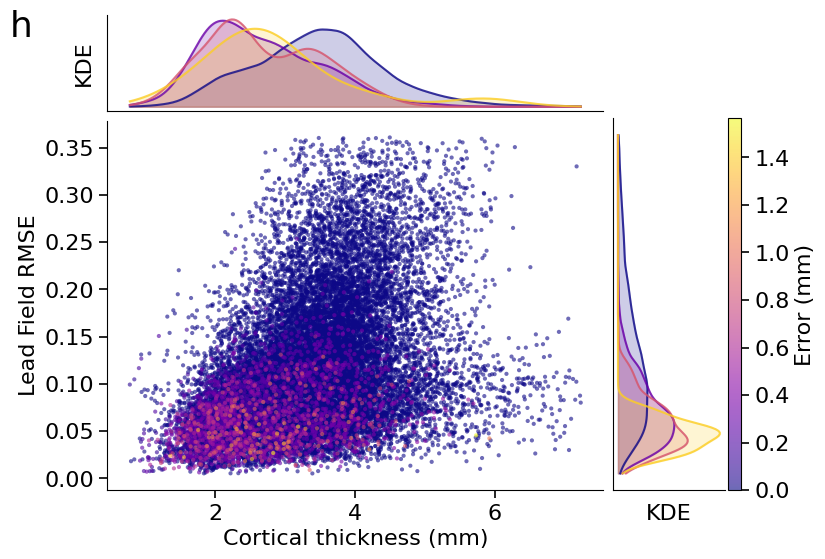

In [263]:
plot_joint_kde(thickness[v_idx], diff_layer_lf_mat[v_idx,-1], error_mm, 'Cortical thickness (mm)', 'Lead Field RMSE','h', x_per=[.1,99.9],y_per=[.1,99.1])
plt.savefig(f"figure_06_thick_lf.pdf", bbox_inches='tight')